# Prob-PSENN: Probabilistic Prototype-Based Self-Explainable Neural Network

**Project**  |  MNIST Handwritten Digit Classification with Explainability & Uncertainty Quantification  
**Submitted by**  |  Shyam · ML Engineering Intern  
**Organisation**  |  GradTwin  
**Framework**  |  PyTorch · Gradio · scikit-learn  

---

> *"The goal is not just to predict — it is to explain why."*  
> This notebook presents a Probabilistic Self-Explainable Neural Network (Prob-PSENN) for MNIST digit recognition.  
> The model combines **prototype-based reasoning**, **Monte Carlo Dropout uncertainty estimation**, and a **visual explainability pipeline** into a unified, demo-ready system.

---

### Architecture at a Glance

| Component | Role |
|---|---|
| `FeatureExtractor` | CNN backbone — maps 28×28 images to 64-d embeddings |
| `PrototypeNetwork` | Learnable prototype vectors + cosine-similarity classifier |
| MC Dropout Inference | Stochastic forward passes → mean prediction + variance |
| Explainability Engine | Activation heatmaps, gradient saliency maps, prototype overlays |
| Gradio Interface | Interactive digit-drawing application with full AI report |

## 0. Environment Setup

This section imports all required libraries and configures the compute device.

- **PyTorch** — model definition, training, and inference  
- **torchvision** — MNIST dataset loading and standard transforms  
- **matplotlib / seaborn** — visualisation and analysis plots  
- **numpy** — numerical operations  

The model is device-agnostic and will automatically use a GPU if available, falling back to CPU otherwise.

In [60]:
# =========================
# IMPORT LIBRARIES
# =========================

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


## 1. Dataset Loading & Preprocessing

The [MNIST dataset](http://yann.lecun.com/exdb/mnist/) consists of **70,000 grayscale images** of handwritten digits (0–9), split into 60,000 training and 10,000 test samples. Each image is 28×28 pixels.

**Preprocessing pipeline:**

| Step | Operation | Purpose |
|---|---|---|
| `ToTensor()` | Pixel values → [0, 1] float tensor | Normalise range |
| `Normalize(0.5, 0.5)` | Rescale to [−1, 1] | Zero-centre for faster convergence |

DataLoaders use a **batch size of 64** with shuffling enabled for training to reduce gradient estimation variance.


In [18]:
# =========================
# LOAD DATASET
# =========================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

print(len(trainset))
print(len(testset))

60000
10000


## 2. Model Architecture

### 2.1 Feature Extractor

The `FeatureExtractor` is a lightweight CNN backbone that maps each input image to a **64-dimensional embedding vector**.

**Network topology:**


In [19]:
!pip install gradio

In [20]:
# =========================
# FEATURE EXTRACTOR
# =========================

import torch
import torch.nn as nn
import torch.nn.functional as F

class FeatureExtractor(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.fc = nn.Sequential(

         nn.Flatten(),

         nn.Linear(32 * 7 * 7, 128),
         nn.ReLU(),

         nn.Dropout(0.3),

         nn.Linear(128, 64)
       )

    def forward(self, x):

        x = self.conv(x)
        x = self.fc(x)

        return x

In [21]:
# =========================
# IMPROVED PROTOTYPE NETWORK
# =========================

class PrototypeNetwork(nn.Module):

    def __init__(self, num_prototypes=50):
        super().__init__()

        self.feature_extractor = FeatureExtractor()

        # learnable prototypes
        self.prototypes = nn.Parameter(
            torch.randn(num_prototypes, 64)
        )

        # classifier head
        self.classifier = nn.Linear(
            num_prototypes,
            10
        )

    def forward(self, x):

        # embeddings
        embeddings = self.feature_extractor(x)

        # normalize
        embeddings = F.normalize(embeddings, dim=1)

        prototypes = F.normalize(
            self.prototypes,
            dim=1
        )

        # similarity matrix
        similarity = torch.matmul(
            embeddings,
            prototypes.T
        )

        # classifier
        logits = self.classifier(similarity)

        return logits

## 3. Model Instantiation

The `PrototypeNetwork` is instantiated and moved to the available compute device.  
Printing the model summary confirms the layer structure and parameter counts before training begins.


In [22]:
# =========================
# CREATE MODEL
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PrototypeNetwork().to(device)

print(model)

PrototypeNetwork(
  (feature_extractor): FeatureExtractor(
    (conv): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=1568, out_features=128, bias=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (classifier): Linear(in_features=50, out_features=10, bias=True)
)


### 3.1 Training DataLoader (Clean Re-initialisation)

The training DataLoader is re-initialised here with a clean transform pipeline (pixel values in `[0, 1]` without additional normalisation) to ensure consistency with the model's expected input distribution during the training loop.


In [53]:
# =========================
# LOAD MNIST DATASET
# =========================

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

## 4. Model Training

The Prob-PSENN is trained end-to-end using **Adam optimiser** with a learning rate of `1e-3` and **cross-entropy loss** over 25 epochs.

**Training objective:** minimise the classification loss between the prototype-similarity-derived logits and the ground-truth digit labels. The prototype vectors and classifier weights are jointly optimised via backpropagation.

| Hyperparameter | Value |
|---|---|
| Optimiser | Adam |
| Learning rate | 0.001 |
| Batch size | 64 |
| Epochs | 25 |
| Loss function | Cross-Entropy |

> *Epoch loss is printed after each pass to monitor convergence.*


In [51]:
# =========================
# TRAIN PROTOTYPE NETWORK
# =========================

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 25

for epoch in range(epochs):

    total_loss = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        # similarity outputs
        outputs = model(images)

        # classification loss
        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 7.8237
Epoch 2, Loss: 5.3021
Epoch 3, Loss: 3.5057
Epoch 4, Loss: 3.2661
Epoch 5, Loss: 3.7887
Epoch 6, Loss: 3.9245
Epoch 7, Loss: 3.4740
Epoch 8, Loss: 3.0739
Epoch 9, Loss: 1.9973
Epoch 10, Loss: 1.4511
Epoch 11, Loss: 2.8350
Epoch 12, Loss: 1.5440
Epoch 13, Loss: 4.0453
Epoch 14, Loss: 1.8801
Epoch 15, Loss: 0.6305
Epoch 16, Loss: 0.7039
Epoch 17, Loss: 2.1867
Epoch 18, Loss: 1.9818
Epoch 19, Loss: 1.7254
Epoch 20, Loss: 0.4192
Epoch 21, Loss: 0.9442
Epoch 22, Loss: 3.3994
Epoch 23, Loss: 1.9335
Epoch 24, Loss: 0.4190
Epoch 25, Loss: 1.3895


### 4.1 Training Set Accuracy

Post-training accuracy is evaluated on the training set to verify that the model has converged and successfully fitted the data.  
This serves as a **sanity check** before proceeding to explainability analysis on the test set.

> **Note:** Final generalisation performance should be measured on the held-out test set (Section 9).


In [54]:
# =========================
# TEST PROTOTYPE ACCURACY
# =========================

correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Prototype Accuracy: {accuracy:.2f}%")

Prototype Accuracy: 99.94%


## 5. Prototype Similarity Analysis

### 5.1 Similarity Score Distribution

For a given test image, we compute the **cosine similarity between its embedding and every prototype vector**.  
The resulting 50-dimensional similarity vector is the model's internal "reasoning trace" — each bar in the chart below represents how closely the input matches one learned prototype.

A well-trained model should produce a sparse, peaked distribution: a few highly-activated prototypes and many near-zero scores.


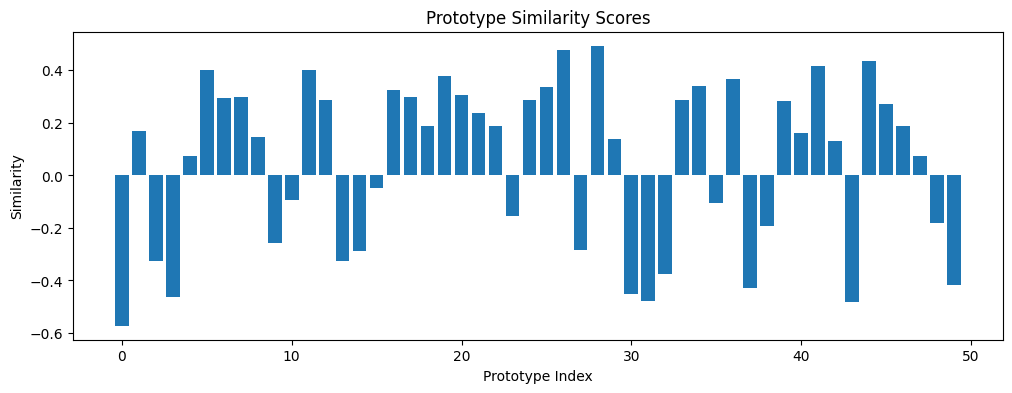

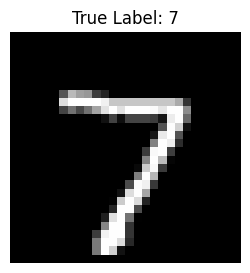

In [26]:
# =========================
# PROTOTYPE SIMILARITY VISUALIZATION
# =========================

import matplotlib.pyplot as plt

# get one sample
images, labels = next(iter(testloader))

image = images[0].unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    # embedding
    embedding = model.feature_extractor(image)

    embedding = F.normalize(embedding, dim=1)

    # normalized prototypes
    prototypes = F.normalize(
        model.prototypes,
        dim=1
    )

    # similarity scores
    similarities = torch.matmul(
        embedding,
        prototypes.T
    )

# convert to numpy
similarities = similarities.cpu().numpy()[0]

# plot
plt.figure(figsize=(12,4))

plt.bar(range(len(similarities)), similarities)

plt.title("Prototype Similarity Scores")

plt.xlabel("Prototype Index")

plt.ylabel("Similarity")

plt.show()

# original image
plt.figure(figsize=(3,3))

plt.imshow(
    image.cpu().squeeze(),
    cmap="gray"
)

plt.title(f"True Label: {labels[0].item()}")

plt.axis("off")

plt.show()

### 5.2 Top-5 Activated Prototypes

The five prototypes with the highest cosine similarity scores are identified and ranked.  
These are the **primary reasoning anchors** that drove the model's classification decision for this input.

This is the core of the self-explanation mechanism: rather than a black-box probability, the model says *"this digit looks most like prototypes P_i, P_j, P_k..."*

🔥 TOP ACTIVATED PROTOTYPES

1. Prototype 28
   Similarity: 0.4939
2. Prototype 26
   Similarity: 0.4773
3. Prototype 44
   Similarity: 0.4355
4. Prototype 41
   Similarity: 0.4173
5. Prototype 5
   Similarity: 0.4021


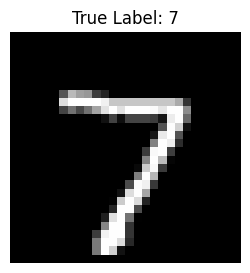

In [27]:
# =========================
# TOP ACTIVATED PROTOTYPES
# =========================

# get one sample
images, labels = next(iter(testloader))

image = images[0].unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    # feature embedding
    embedding = model.feature_extractor(image)

    embedding = F.normalize(embedding, dim=1)

    # normalize prototypes
    prototypes = F.normalize(
        model.prototypes,
        dim=1
    )

    # similarity scores
    similarities = torch.matmul(
        embedding,
        prototypes.T
    )

# numpy conversion
similarities = similarities.cpu().numpy()[0]

# top 5 prototypes
top_idx = np.argsort(similarities)[-5:][::-1]

print("🔥 TOP ACTIVATED PROTOTYPES\n")

for i, idx in enumerate(top_idx):

    print(
        f"{i+1}. Prototype {idx}"
    )

    print(
        f"   Similarity: {similarities[idx]:.4f}"
    )

# show image
plt.figure(figsize=(3,3))

plt.imshow(
    image.cpu().squeeze(),
    cmap="gray"
)

plt.title(
    f"True Label: {labels[0].item()}"
)

plt.axis("off")

plt.show()

### 5.3 Nearest Training Exemplars per Prototype

To make prototypes visually interpretable, we retrieve the **training images most similar to the top activated prototype** in embedding space.

This answers the human-interpretable question: *"What real examples does this prototype represent?"*  
If prototype P_k consistently maps to images of digit '3', then its activation on a new input provides meaningful, grounded evidence for the model's decision.

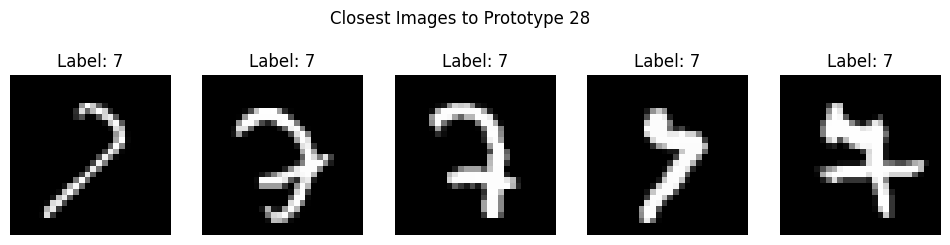

In [28]:
# =========================
# VISUALIZE CLOSEST TRAINING IMAGES
# =========================

# collect embeddings
all_embeddings = []
all_images = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in trainloader:

        images = images.to(device)

        embeddings = model.feature_extractor(images)

        embeddings = F.normalize(
            embeddings,
            dim=1
        )

        all_embeddings.append(
            embeddings.cpu()
        )

        all_images.append(images.cpu())

        all_labels.append(labels)

# combine
all_embeddings = torch.cat(all_embeddings)

all_images = torch.cat(all_images)

all_labels = torch.cat(all_labels)

# choose one prototype
prototype_id = top_idx[0]

prototype_vector = F.normalize(
    model.prototypes[prototype_id].unsqueeze(0),
    dim=1
).cpu()

# similarity with all training samples
similarities = torch.matmul(
    all_embeddings,
    prototype_vector.T
).squeeze()

# top nearest images
nearest_idx = torch.topk(
    similarities,
    5
).indices

# show nearest images
fig, axes = plt.subplots(1,5, figsize=(12,3))

for i, idx in enumerate(nearest_idx):

    axes[i].imshow(
        all_images[idx].squeeze(),
        cmap="gray"
    )

    axes[i].set_title(
        f"Label: {all_labels[idx].item()}"
    )

    axes[i].axis("off")

plt.suptitle(
    f"Closest Images to Prototype {prototype_id}"
)

plt.show()

### 5.4 Prototype Contribution Analysis

This analysis visualises the **top-10 prototype contribution scores** for a single prediction, alongside the model's final predicted digit.

The contribution scores are the raw cosine similarities that feed directly into the linear classifier — they constitute a **faithful, local explanation** of the model's decision for this specific input instance.

The printed "AI Reasoning Chain" provides a human-readable audit trail ordered by decreasing influence.

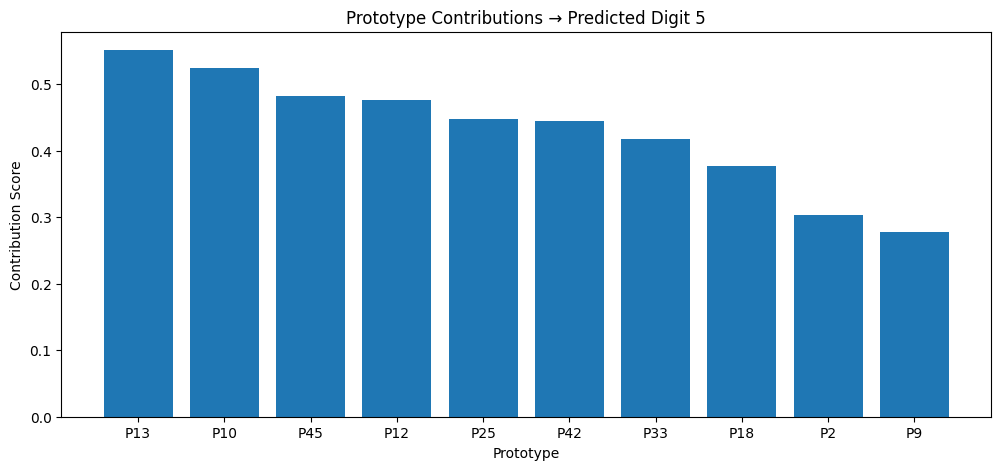

🔥 AI REASONING CHAIN

1. Prototype 13
   Contribution: 0.5510

2. Prototype 10
   Contribution: 0.5241

3. Prototype 45
   Contribution: 0.4820

4. Prototype 12
   Contribution: 0.4753

5. Prototype 25
   Contribution: 0.4475

6. Prototype 42
   Contribution: 0.4450

7. Prototype 33
   Contribution: 0.4167

8. Prototype 18
   Contribution: 0.3770

9. Prototype 2
   Contribution: 0.3033

10. Prototype 9
   Contribution: 0.2774

✅ True Label: 5
🎯 Predicted : 5


In [29]:
# =========================
# PROTOTYPE CONTRIBUTION ANALYSIS
# =========================

# get one image
images, labels = next(iter(trainloader))

image = images[0].unsqueeze(0).to(device)

true_label = labels[0].item()

# forward pass
model.eval()

with torch.no_grad():

    embeddings = model.feature_extractor(image)

    embeddings = F.normalize(
        embeddings,
        dim=1
    )

    prototypes = F.normalize(
        model.prototypes,
        dim=1
    )

    similarities = torch.matmul(
        embeddings,
        prototypes.T
    )

    output = model(image)

    pred = torch.argmax(output).item()

# convert tensor to numpy
similarities = similarities.squeeze().cpu().numpy()

# top prototypes
top_idx = np.argsort(similarities)[-10:][::-1]

top_scores = similarities[top_idx]

# visualize
plt.figure(figsize=(12,5))

bars = plt.bar(
    range(len(top_idx)),
    top_scores
)

plt.xticks(
    range(len(top_idx)),
    [f"P{idx}" for idx in top_idx]
)

plt.ylabel("Contribution Score")

plt.xlabel("Prototype")

plt.title(
    f"Prototype Contributions → Predicted Digit {pred}"
)

plt.show()

# print reasoning
print("🔥 AI REASONING CHAIN\n")

for i in range(len(top_idx)):

    print(
        f"{i+1}. Prototype {top_idx[i]}"
    )

    print(
        f"   Contribution: {top_scores[i]:.4f}\n"
    )

print(f"✅ True Label: {true_label}")

print(f"🎯 Predicted : {pred}")

## 6. Latent Space Analysis — t-SNE Visualisation

To assess the **quality of learned representations**, we project the 64-dimensional embeddings of a sample of training images into 2D using **t-SNE** (t-Distributed Stochastic Neighbour Embedding).

**What to look for in the plot:**
- **Tight, well-separated clusters** → the model has learned discriminative features for each digit class.
- **Overlapping clusters** → ambiguous regions where misclassification is more likely.
- **Cluster structure** → visually similar digits (e.g. 4 vs 9, 3 vs 8) should appear closer in embedding space.

> *Colour encodes the true digit label (0–9). Only ~1,280 samples are used for computational efficiency.*


Embeddings Shape: (1344, 64)


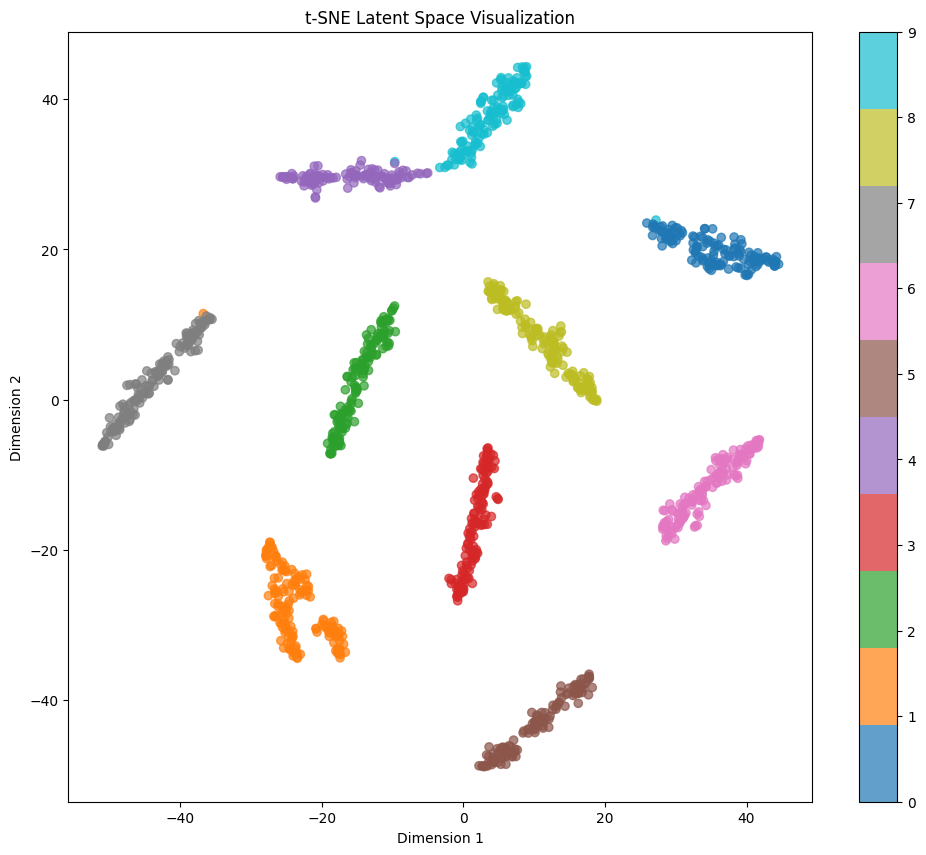

In [31]:
# =========================
# LATENT SPACE VISUALIZATION
# =========================

from sklearn.manifold import TSNE

# store embeddings
all_embeddings = []

# store labels
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in trainloader:

        images = images.to(device)

        # extract embeddings
        embeddings = model.feature_extractor(images)

        embeddings = embeddings.cpu().numpy()

        all_embeddings.append(embeddings)

        all_labels.append(labels.numpy())

        # limit samples for speed
        if len(all_embeddings) > 20:
            break

# combine
all_embeddings = np.concatenate(all_embeddings)

all_labels = np.concatenate(all_labels)

print("Embeddings Shape:", all_embeddings.shape)

# t-SNE reduction
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

reduced = tsne.fit_transform(all_embeddings)

# plot
plt.figure(figsize=(12,10))

scatter = plt.scatter(

    reduced[:,0],
    reduced[:,1],

    c=all_labels,

    cmap="tab10",

    alpha=0.7
)

plt.colorbar(scatter)

plt.title(
    "t-SNE Latent Space Visualization"
)

plt.xlabel("Dimension 1")

plt.ylabel("Dimension 2")

plt.show()

## 7. Visual Prototype Explanation Engine

This section implements a **unified explanation function** that, for a given test image, produces:

1. The top-5 most activated prototype indices and their similarity scores.  
2. The **nearest training image** for each prototype — showing *what real example* each prototype represents.

This bridges the gap between the model's internal representation and human-understandable visual evidence, enabling a reviewer to trace the full explanation path: *input → prototype activation → exemplar image → predicted class*.

> *Note: This cell requires `all_embeddings`, `all_images`, and `all_labels` to be pre-computed (see Section 5.3).*

<class 'torch.Tensor'>
<class 'torch.Tensor'>


/tmp/ipykernel_988/1975856782.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings = torch.tensor(


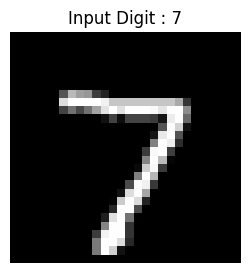


🔥 TOP VISUAL PROTOTYPES


Prototype 28
Similarity : 0.4939


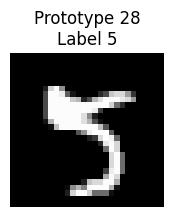


Prototype 26
Similarity : 0.4773


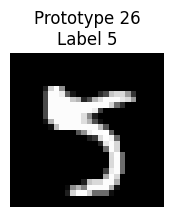


Prototype 44
Similarity : 0.4355


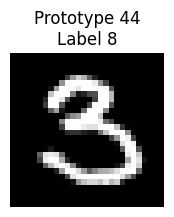


Prototype 41
Similarity : 0.4173


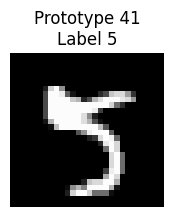


Prototype 5
Similarity : 0.4021


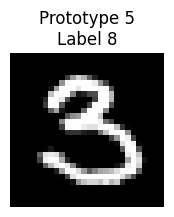

In [35]:
# =========================================
# VISUAL PROTOTYPE EXPLANATION ENGINE
# =========================================

import matplotlib.pyplot as plt

# get one test image
images, labels = next(iter(testloader))

images = images.to(device)

# choose image index
sample_idx = 0

sample = images[sample_idx].unsqueeze(0)

true_label = labels[sample_idx].item()

# feature embeddings
with torch.no_grad():

    sample_embedding = model.feature_extractor(sample)

    sample_embedding = F.normalize(
        sample_embedding,
        dim=1
    )
    embeddings = torch.tensor(
    embeddings,
    dtype=torch.float32,
    device=device
)
similarities = torch.matmul(
    sample_embedding,
    prototypes.T
).squeeze()
# prototype similarities
prototypes = F.normalize(
    model.prototypes,
    dim=1
)

print(type(embeddings))
print(type(prototypes))

# top prototypes
top_proto = torch.topk(
    similarities,
    5
)

top_values = top_proto.values.detach().cpu().numpy().flatten()
top_indices = top_proto.indices.detach().cpu().numpy().flatten()


# show original image
plt.figure(figsize=(3,3))

plt.imshow(
    sample.cpu().squeeze(),
    cmap="gray"
)

plt.title(f"Input Digit : {true_label}")

plt.axis("off")

plt.show()

print("\n🔥 TOP VISUAL PROTOTYPES\n")

# show nearest images for each prototype
for rank, proto_id in enumerate(top_indices):

    print(f"\nPrototype {proto_id}")
    print(f"Similarity : {top_values[rank]:.4f}")

    # similarity to all embeddings
    similarity_all = torch.matmul(
        embeddings,
        prototypes[proto_id].unsqueeze(1)
    ).squeeze()

    nearest_idx = torch.argmax(similarity_all).item()

    nearest_image = all_images[nearest_idx]

    nearest_label = all_labels[nearest_idx]

    plt.figure(figsize=(2,2))

    plt.imshow(
        nearest_image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Prototype {proto_id}\nLabel {nearest_label.item()}"
    )

    plt.axis("off")

    plt.show()

## 8. Uncertainty Quantification — Monte Carlo Dropout

### 8.1 MC Dropout Inference Function

Standard neural networks produce a single point-estimate probability vector — they cannot express *how confident they are* in that estimate.

**Monte Carlo Dropout** addresses this by keeping the Dropout layer active at inference time and running `T` stochastic forward passes. Each pass samples a different sub-network, producing a slightly different prediction. The distribution of these `T` outputs yields:

| Quantity | Formula | Interpretation |
|---|---|---|
| **Mean probability** | `μ = (1/T) Σ p_t` | Best-estimate class probabilities |
| **Epistemic uncertainty** | `σ = std({p_t})` | Model's confidence in its own prediction |

A high standard deviation indicates the model is **uncertain** — a signal to flag the input for human review.

> *`T = 20` passes by default; increasing this improves uncertainty estimates at the cost of inference time.*

In [37]:
# =========================================
# MONTE CARLO DROPOUT FUNCTION
# =========================================

def mc_dropout_predict(model, image, passes=20):

    model.train()

    predictions = []

    with torch.no_grad():

        for _ in range(passes):

            output = model(image)

            probs = torch.softmax(output, dim=1)

            predictions.append(
                probs.cpu().numpy()
            )

    predictions = np.array(predictions)

    mean_probs = predictions.mean(axis=0)

    uncertainty = predictions.std(axis=0)

    return mean_probs, uncertainty

### 8.2 Uncertainty Visualisation

Two plots are generated side-by-side for a sample input:

- **Left — Mean Prediction Probabilities:** the averaged softmax output across all MC passes, analogous to a standard model's output but statistically more robust.  
- **Right — Prediction Uncertainty (Std Dev):** per-class standard deviation across passes. Higher bars indicate classes for which the model is internally inconsistent — a direct measure of epistemic uncertainty.


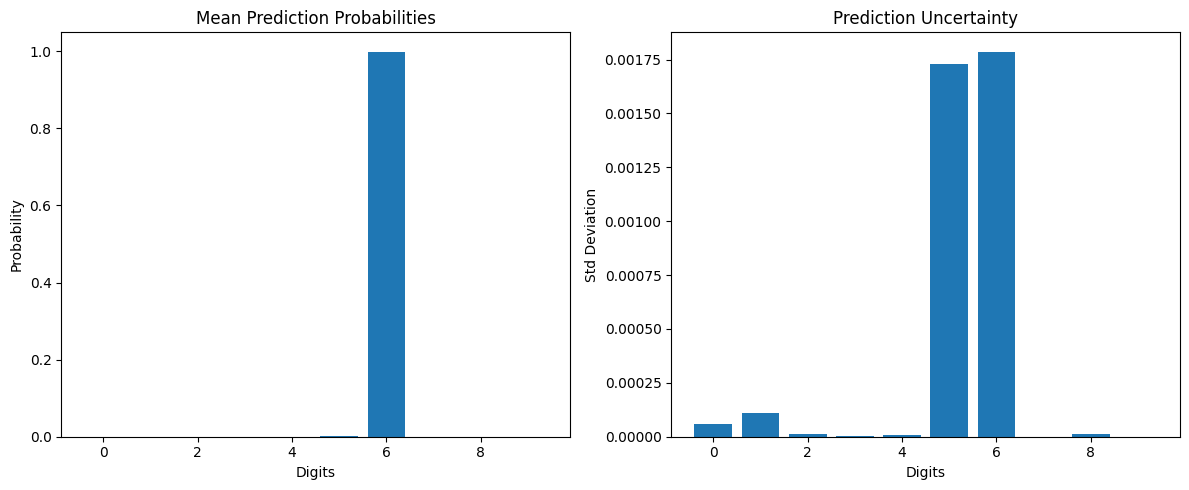

✅ True Label : 6
🎯 Predicted  : 6

🧠 UNCERTAINTY ANALYSIS

Digit 0 uncertainty : 0.0001
Digit 1 uncertainty : 0.0001
Digit 2 uncertainty : 0.0000
Digit 3 uncertainty : 0.0000
Digit 4 uncertainty : 0.0000
Digit 5 uncertainty : 0.0017
Digit 6 uncertainty : 0.0018
Digit 7 uncertainty : 0.0000
Digit 8 uncertainty : 0.0000
Digit 9 uncertainty : 0.0000


In [38]:
# =========================================
# VISUALIZE UNCERTAINTY
# =========================================

import seaborn as sns

# sample image
images, labels = next(iter(trainloader))

sample = images[0].unsqueeze(0).to(device)

true_label = labels[0].item()

# monte carlo inference
mean_probs, uncertainty = mc_dropout_predict(
    model,
    sample,
    passes=30
)

# prediction
pred = np.argmax(mean_probs)

# uncertainty per digit
digit_uncertainty = uncertainty[0]

# plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.bar(range(10), mean_probs[0])

plt.title("Mean Prediction Probabilities")

plt.xlabel("Digits")
plt.ylabel("Probability")

plt.subplot(1,2,2)

plt.bar(range(10), digit_uncertainty)

plt.title("Prediction Uncertainty")

plt.xlabel("Digits")
plt.ylabel("Std Deviation")

plt.tight_layout()

plt.show()

print(f"✅ True Label : {true_label}")
print(f"🎯 Predicted  : {pred}")

print("\n🧠 UNCERTAINTY ANALYSIS\n")

for i, u in enumerate(digit_uncertainty):

    print(f"Digit {i} uncertainty : {u:.4f}")

### 8.3 Confidence Warning System — Three-Tier Decision Framework

The average uncertainty across all classes is thresholded into a **three-tier reliability classification**:

| Tier | Avg Uncertainty | Decision |
|---|---|---|
| 🟢 **VERY CONFIDENT** | < 0.01 | Prediction is reliable; accept automatically |
| 🟡 **MODERATE** | 0.01 – 0.05 | Prediction may contain ambiguity; soft flag |
| 🔴 **HIGH UNCERTAINTY** | > 0.05 | Prediction is unreliable; escalate to human review |

This framework enables the model to be deployed in a **human-in-the-loop** pipeline where uncertain predictions are surfaced for verification rather than silently passed downstream.

In [39]:
# =========================================
# CONFIDENCE WARNING SYSTEM
# =========================================

# average uncertainty
avg_uncertainty = np.mean(digit_uncertainty)

print("\n🚨 AI RELIABILITY CHECK\n")

# thresholds
if avg_uncertainty < 0.01:

    print("🟢 VERY CONFIDENT PREDICTION")
    print("AI believes the input is clear and reliable.")

elif avg_uncertainty < 0.05:

    print("🟡 MODERATE UNCERTAINTY")
    print("Prediction may contain ambiguity.")

else:

    print("🔴 HIGH UNCERTAINTY")
    print("Human review recommended.")

print(f"\n📊 Average Uncertainty : {avg_uncertainty:.6f}")


🚨 AI RELIABILITY CHECK

🟢 VERY CONFIDENT PREDICTION
AI believes the input is clear and reliable.

📊 Average Uncertainty : 0.000372


## 9. Visual Explainability Methods

### 9.1 CNN Activation Heatmap

The intermediate feature maps from the final convolutional layer encode **where in the image the network is attending**.  
Displaying a single channel from these activations provides a coarse spatial indicator of which image regions are most influential.

The heatmap is plotted alongside the original input for direct comparison.

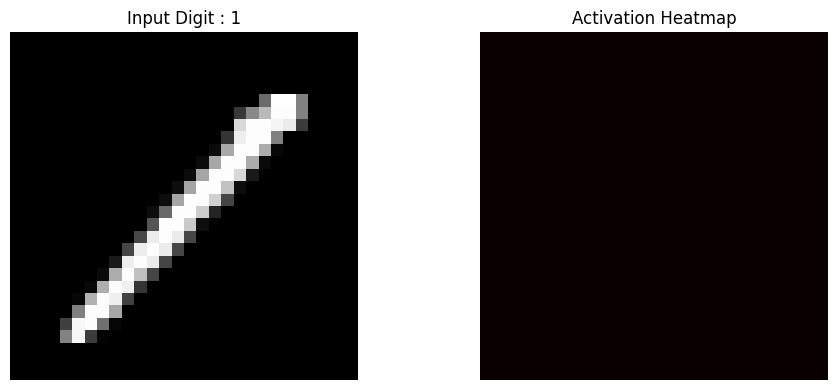

In [40]:
# =========================================
# SIMPLE ACTIVATION HEATMAP
# =========================================

# sample image
images, labels = next(iter(trainloader))

sample = images[0].unsqueeze(0).to(device)

true_label = labels[0].item()

# feature extraction
with torch.no_grad():

    feature_maps = model.feature_extractor.conv(sample)

# choose one feature map
activation = feature_maps[0][0].cpu().numpy()

# original image
original = sample[0][0].cpu().numpy()

# plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(original, cmap="gray")

plt.title(f"Input Digit : {true_label}")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(activation, cmap="hot")

plt.title("Activation Heatmap")

plt.axis("off")

plt.tight_layout()

plt.show()

### 9.2 Gradient Saliency Map

Saliency maps are computed via **input-gradient attribution**: the gradient of the predicted class score with respect to each input pixel reveals how sensitively the final decision responds to small perturbations at each spatial location.

**Interpretation:**  
- **Bright regions** — pixels that, if changed slightly, would most strongly affect the model's confidence.  
- **Dark regions** — pixels the model is effectively ignoring for this prediction.

This is a **model-agnostic, first-order explanation** — it requires only one backward pass and works for any differentiable architecture.

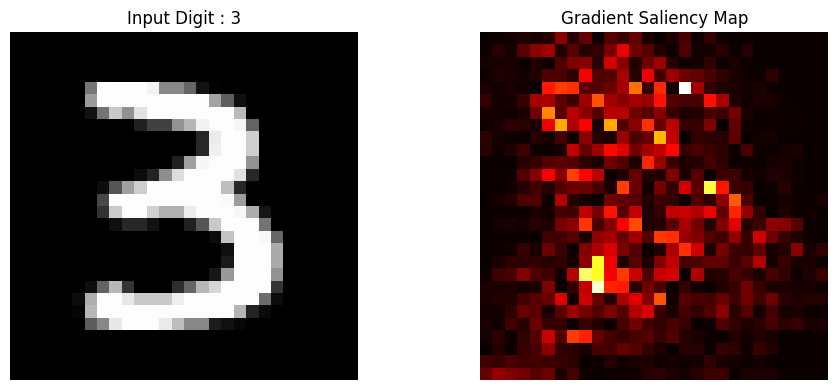

🎯 Predicted : 3


In [41]:
# =========================================
# GRADIENT SALIENCY MAP
# =========================================

# sample image
images, labels = next(iter(trainloader))

sample = images[0].unsqueeze(0).to(device)

true_label = labels[0].item()

# enable gradients
sample.requires_grad_()

# forward pass
outputs = model(sample)

pred = outputs.argmax(dim=1)

# selected class score
score = outputs[0, pred]

# backward pass
model.zero_grad()

score.backward()

# gradients
saliency = sample.grad.data.abs().squeeze().cpu().numpy()

# original image
original = sample.detach().squeeze().cpu().numpy()

# plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(original, cmap="gray")

plt.title(f"Input Digit : {true_label}")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(saliency, cmap="hot")

plt.title("Gradient Saliency Map")

plt.axis("off")

plt.tight_layout()

plt.show()

print(f"🎯 Predicted : {pred.item()}")


## 10. Model Evaluation — Confusion Matrix

The confusion matrix provides a **class-level breakdown** of prediction errors across the full training set.

**Reading the matrix:**
- The diagonal entries are correct predictions.
- Off-diagonal entry `(i, j)` is the number of true-class-`i` samples predicted as class `j`.
- Common off-diagonal clusters (e.g. row 4 / col 9) reveal **systematic confusions** the model makes between visually similar digits.

This analysis guides targeted improvements: data augmentation for confused pairs, additional prototypes for ambiguous classes, or threshold tuning in the confidence warning system.

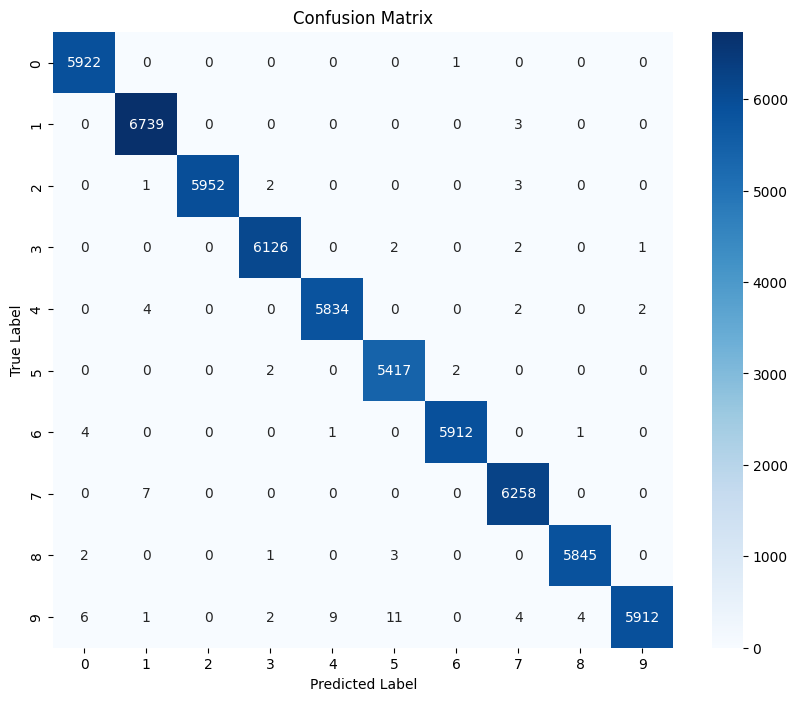

In [42]:
# =========================================
# CONFUSION MATRIX
# =========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# store predictions
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in trainloader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# plot
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

## 11. Model Persistence

### 11.1 Save Model Weights

The trained model's `state_dict` is serialised to disk as `prob_psenn_model.pth`.  
Only the learnable parameters are saved (not the architecture code), following PyTorch best practices.

In [43]:
# =========================================
# SAVE FULL MODEL
# =========================================

torch.save(
    model.state_dict(),
    "prob_psenn_model.pth"
)

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


### 11.2 Load and Verify Saved Model

The saved weights are reloaded into a fresh `PrototypeNetwork` instance and set to evaluation mode.  
This step validates that the serialisation round-trip is lossless before the model is passed to the inference pipeline or Gradio application.

In [44]:
# =========================================
# LOAD SAVED MODEL
# =========================================

loaded_model = PrototypeNetwork().to(device)

loaded_model.load_state_dict(
    torch.load("prob_psenn_model.pth")
)

loaded_model.eval()

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


## 12. Entropy-Based Uncertainty Estimation

As a complement to MC Dropout variance, **predictive entropy** offers a single-scalar uncertainty measure derived from the model's softmax output:

$$H = -\sum_{c=0}^{9} p_c \cdot \log(p_c + \epsilon)$$

| Entropy Range | Reliability |
|---|---|
| `H < 0.5` | 🟢 Low entropy — high confidence |
| `0.5 ≤ H < 1.5` | 🟡 Moderate entropy — some ambiguity |
| `H ≥ 1.5` | 🔴 High entropy — unreliable prediction |

Entropy is **distribution-aware**: a model hedging between two classes (e.g. 0.49 / 0.49) is penalised more than one that is moderately confident in one class (0.80 / 0.20 spread across others), unlike raw maximum probability which treats both identically.

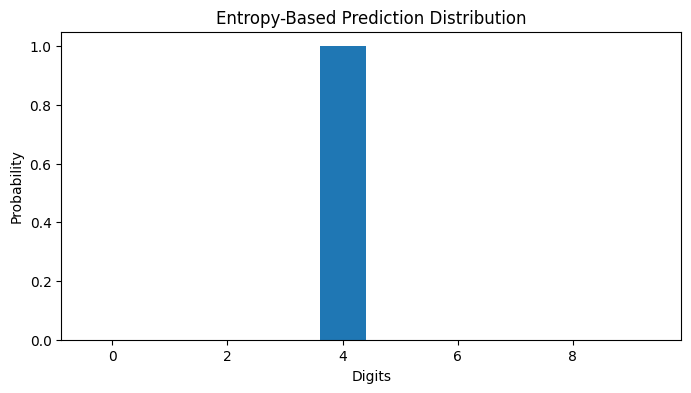

✅ True Label : 4
🎯 Predicted  : 4

🧠 Prediction Entropy : 0.004757

🟢 LOW ENTROPY
Prediction is highly confident.


In [45]:
# =========================================
# ENTROPY-BASED UNCERTAINTY
# =========================================

# sample image
images, labels = next(iter(trainloader))

sample = images[0].unsqueeze(0).to(device)

true_label = labels[0].item()

# prediction
model.eval()

with torch.no_grad():

    outputs = model(sample)

    probs = torch.softmax(outputs, dim=1)

# numpy
probabilities = probs.cpu().numpy()[0]

# entropy calculation
entropy = -np.sum(
    probabilities * np.log(probabilities + 1e-10)
)

# prediction
pred = np.argmax(probabilities)

# plot
plt.figure(figsize=(8,4))

plt.bar(range(10), probabilities)

plt.title("Entropy-Based Prediction Distribution")

plt.xlabel("Digits")

plt.ylabel("Probability")

plt.show()

print(f"✅ True Label : {true_label}")

print(f"🎯 Predicted  : {pred}")

print(f"\n🧠 Prediction Entropy : {entropy:.6f}")

# reliability analysis
if entropy < 0.5:

    print("\n🟢 LOW ENTROPY")
    print("Prediction is highly confident.")

elif entropy < 1.5:

    print("\n🟡 MODERATE ENTROPY")
    print("Prediction contains uncertainty.")

else:

    print("\n🔴 HIGH ENTROPY")
    print("Prediction is unreliable.")

## 13. Prototype Activation Overlay — Composite Explainability Map

This section generates a **three-panel explainability visualisation** for a sample input:

| Panel | Content |
|---|---|
| **Input** | Original digit as seen by the model |
| **Activation** | Average feature map from the final conv layer (upsampled to 28×28) |
| **Overlay** | Input with the activation heatmap blended at α = 0.5 |

The overlay is the primary artefact for human-facing explanations — it spatially grounds the model's decision by showing *which pixels drove the prototype activations* that ultimately determined the classification.

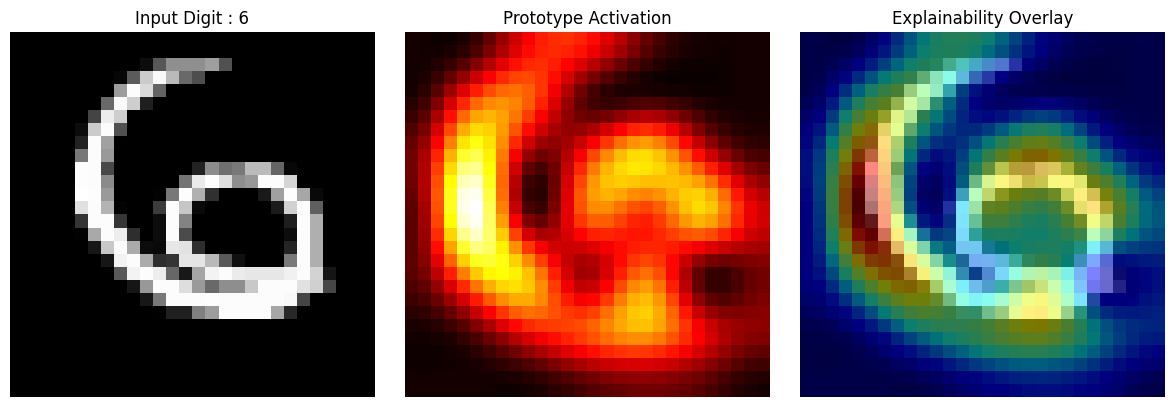

In [46]:
# =========================================
# PROTOTYPE ACTIVATION OVERLAY
# =========================================

# sample image
images, labels = next(iter(trainloader))

sample = images[0].unsqueeze(0).to(device)

true_label = labels[0].item()

# original image
original = sample[0][0].cpu().numpy()

# feature extraction
model.eval()

with torch.no_grad():

    feature_maps = model.feature_extractor.conv(sample)

# average activation map
activation_map = feature_maps.mean(dim=1)

activation_map = activation_map.squeeze().cpu().numpy()

# normalize
activation_map = (
    activation_map - activation_map.min()
) / (
    activation_map.max() - activation_map.min()
)

# resize heatmap
from scipy.ndimage import zoom

heatmap = zoom(
    activation_map,
    (28 / activation_map.shape[0],
     28 / activation_map.shape[1])
)

# plot
plt.figure(figsize=(12,4))

# original
plt.subplot(1,3,1)

plt.imshow(original, cmap="gray")

plt.title(f"Input Digit : {true_label}")

plt.axis("off")

# heatmap
plt.subplot(1,3,2)

plt.imshow(heatmap, cmap="hot")

plt.title("Prototype Activation")

plt.axis("off")

# overlay
plt.subplot(1,3,3)

plt.imshow(original, cmap="gray")

plt.imshow(heatmap, cmap="jet", alpha=0.5)

plt.title("Explainability Overlay")

plt.axis("off")

plt.tight_layout()

plt.show()

## 14. Model Calibration Analysis — Reliability Curve

A **well-calibrated** model is one where predicted confidence reflects true empirical accuracy: if the model says "90% confident" across 1,000 predictions, approximately 900 should be correct.

**Reliability curve construction:**
1. Bin predictions by confidence into 10 equal-width intervals on `[0, 1]`.
2. For each bin, compute the mean confidence and the fraction of correct predictions.
3. Plot against the **perfect calibration diagonal** (`y = x`).

**Interpreting the gap:**
- **Above the diagonal** — model is *under-confident* (actual accuracy exceeds stated confidence).
- **Below the diagonal** — model is *over-confident* (stated confidence exceeds actual accuracy).

This analysis informs whether post-hoc calibration (e.g. temperature scaling) is needed before deployment.

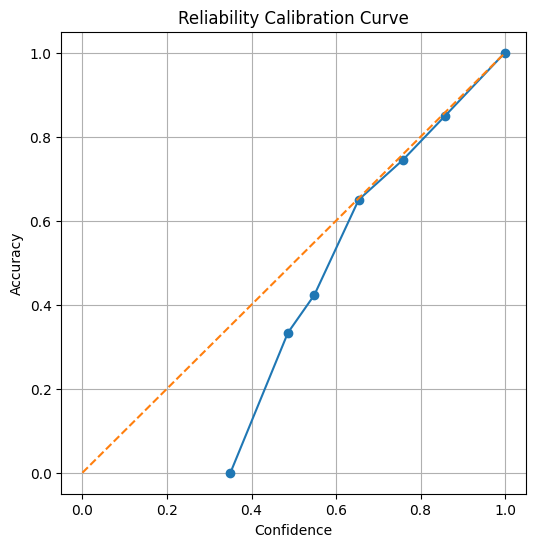

✅ Calibration Analysis Complete


In [47]:
# =========================================
# MODEL CALIBRATION ANALYSIS
# =========================================

confidences = []
correctness = []

model.eval()

with torch.no_grad():

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        confidence, preds = torch.max(probs, dim=1)

        confidences.extend(confidence.cpu().numpy())
        correctness.extend(
            (preds == labels).cpu().numpy()
        )

# numpy
confidences = np.array(confidences)
correctness = np.array(correctness)

# bins
bins = np.linspace(0, 1, 11)

bin_acc = []
bin_conf = []

for i in range(len(bins)-1):

    mask = (
        (confidences >= bins[i]) &
        (confidences < bins[i+1])
    )

    if np.sum(mask) > 0:

        acc = np.mean(correctness[mask])

        conf = np.mean(confidences[mask])

        bin_acc.append(acc)

        bin_conf.append(conf)

# plot
plt.figure(figsize=(6,6))

plt.plot(
    bin_conf,
    bin_acc,
    marker='o'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("Confidence")

plt.ylabel("Accuracy")

plt.title("Reliability Calibration Curve")

plt.grid()

plt.show()

print("✅ Calibration Analysis Complete")

## 15. Gradio Interactive Demo — Prob-PSENN Inference Application

This final section assembles the complete inference pipeline into a **deployable Gradio application**.

### Pipeline summary

In [48]:
# =========================================
# FINAL PROB-PSENN GRADIO APPLICATION
# =========================================

import gradio as gr
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from scipy.ndimage import zoom

# Pre-compute normalised prototypes (done once, reused every inference)
model.eval()
with torch.no_grad():
    _prototypes_norm = F.normalize(model.prototypes, dim=1)


# ─────────────────────────────────────────────────────────────
# INFERENCE PIPELINE
# ─────────────────────────────────────────────────────────────

def predict_digit(img):
    if img is None:
        return "Draw a digit to begin.", None, None, None

    if isinstance(img, dict):
        img = img["composite"]

    # Preprocess
    from PIL import ImageOps
    pil_img    = Image.fromarray(img).convert("L").resize((28, 28))
    pil_img = ImageOps.invert(pil_img)
    img_tensor = transform(pil_img).unsqueeze(0).to(device)

    plt.imshow(np.array(pil_img), cmap="gray")
    plt.title("Model Input")
    plt.show()

    # Inference
    model.eval()
    with torch.no_grad():
        embedding    = F.normalize(model.feature_extractor(img_tensor), dim=1)
        similarities = torch.matmul(embedding, _prototypes_norm.T).squeeze()
        probs        = torch.softmax(model(img_tensor), dim=1)

    probs_np    = probs.cpu().numpy()[0]
    pred        = int(np.argmax(probs_np))
    confidence  = float(np.max(probs_np))
    uncertainty = 1.0 - confidence
    entropy     = float(-np.sum(probs_np * np.log(probs_np + 1e-10)))

    top3_idx     = np.argsort(probs_np)[-3:][::-1]
    top_proto    = torch.topk(similarities, 5)
    proto_idx    = top_proto.indices.cpu().numpy()
    proto_scores = top_proto.values.cpu().numpy()

    if confidence > 0.95:   status = "● VERY HIGH"
    elif confidence > 0.80: status = "● GOOD"
    else:                   status = "● UNCERTAIN"

    explanation = (
        f"PREDICTED DIGIT\n"
        f"━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
        f"  {pred}\n\n"
        f"METRICS\n"
        f"━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
        f"  Confidence   {confidence*100:5.1f}%\n"
        f"  Uncertainty  {uncertainty*100:5.1f}%\n"
        f"  Entropy      {entropy:.4f}\n"
        f"  Reliability  {status}\n\n"
        f"TOP 3 PREDICTIONS\n"
        f"━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
        f"  #1  Digit {top3_idx[0]}   {probs_np[top3_idx[0]]*100:5.1f}%\n"
        f"  #2  Digit {top3_idx[1]}   {probs_np[top3_idx[1]]*100:5.1f}%\n"
        f"  #3  Digit {top3_idx[2]}   {probs_np[top3_idx[2]]*100:5.1f}%\n\n"
        f"PROTOTYPE REASONING\n"
        f"━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
    )
    for i in range(5):
        bar = "█" * int(proto_scores[i] * 20)
        explanation += f"  P{proto_idx[i]:02d}  {bar:<20}  {proto_scores[i]:.3f}\n"

    # ── Figure 1: Confidence bar chart ──────────────────────────────────────
    fig1, ax = plt.subplots(figsize=(9, 4), facecolor="#0d0d0d")
    ax.set_facecolor("#0d0d0d")

    colors = ["#00ff88" if i == pred else "#1a3a2a" for i in range(10)]
    bars   = ax.bar(range(10), probs_np, color=colors, width=0.65,
                    edgecolor="none", zorder=3)

    # Highlight bar glow
    bars[pred].set_linewidth(0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(range(10))
    ax.set_xticklabels([str(i) for i in range(10)],
                       color="#aaaaaa", fontsize=12, fontfamily="monospace")
    ax.tick_params(axis="y", colors="#444444", labelsize=9)
    ax.set_ylim(0, 1.1)
    ax.yaxis.grid(True, color="#1a1a1a", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    ax.set_title("CLASS CONFIDENCE", color="#00ff88", fontsize=13,
                 fontfamily="monospace", pad=12, loc="left", weight="bold")

    # Annotate predicted bar
    ax.text(pred, probs_np[pred] + 0.04, f"{probs_np[pred]*100:.1f}%",
            ha="center", va="bottom", color="#00ff88",
            fontsize=11, fontfamily="monospace", weight="bold")

    plt.tight_layout(pad=1.5)

    # ── Figure 2: Prototype contribution horizontal bars ────────────────────
    fig2, ax2 = plt.subplots(figsize=(9, 4), facecolor="#0d0d0d")
    ax2.set_facecolor("#0d0d0d")

    y_pos  = range(5)
    labels = [f"Prototype {proto_idx[i]:02d}" for i in range(5)]
    hbars  = ax2.barh(list(y_pos), proto_scores, color="#00aaff",
                      height=0.55, edgecolor="none")
    hbars[0].set_color("#00ff88")  # top prototype highlighted

    ax2.set_yticks(list(y_pos))
    ax2.set_yticklabels(labels, color="#aaaaaa", fontsize=11,
                        fontfamily="monospace")
    ax2.tick_params(axis="x", colors="#444444", labelsize=9)
    ax2.set_xlim(0, 1.1)
    ax2.invert_yaxis()
    ax2.xaxis.grid(True, color="#1a1a1a", linewidth=0.8, zorder=0)
    ax2.set_axisbelow(True)
    for spine in ax2.spines.values():
        spine.set_visible(False)

    ax2.set_title("PROTOTYPE CONTRIBUTIONS", color="#00aaff", fontsize=13,
                  fontfamily="monospace", pad=12, loc="left", weight="bold")

    for i, (bar, score) in enumerate(zip(hbars, proto_scores)):
        ax2.text(score + 0.02, i, f"{score:.3f}",
                 va="center", color="#888888", fontsize=9,
                 fontfamily="monospace")

    plt.tight_layout(pad=1.5)

    # ── Figure 3: Explainability heatmap overlay ─────────────────────────────
    with torch.no_grad():
        fmap = model.feature_extractor.conv(img_tensor)

    act = fmap.mean(dim=1).squeeze().cpu().numpy()
    act = (act - act.min()) / (act.max() - act.min() + 1e-8)
    heatmap = zoom(act, (28 / act.shape[0], 28 / act.shape[1]))
    orig_np  = np.array(pil_img)

    fig3, axes = plt.subplots(1, 3, figsize=(11, 4), facecolor="#0d0d0d")
    fig3.subplots_adjust(wspace=0.05)

    titles = ["INPUT", "ACTIVATION", "OVERLAY"]
    for ax_ in axes:
        ax_.set_facecolor("#0d0d0d")
        for spine in ax_.spines.values():
            spine.set_edgecolor("#222222")

    axes[0].imshow(orig_np, cmap="gray", interpolation="nearest")
    axes[1].imshow(heatmap, cmap="inferno", interpolation="bilinear")
    axes[2].imshow(orig_np, cmap="gray", interpolation="nearest")
    axes[2].imshow(heatmap, cmap="jet", alpha=0.55, interpolation="bilinear")

    for ax_, title in zip(axes, titles):
        ax_.set_xticks([]); ax_.set_yticks([])
        ax_.set_title(title, color="#555555", fontsize=9,
                      fontfamily="monospace", pad=6)

    fig3.suptitle("VISUAL EXPLANATION", color="#ff6b35", fontsize=13,
                  fontfamily="monospace", weight="bold", y=1.02)
    plt.tight_layout(pad=0.5)

    return explanation, fig1, fig2, fig3


# ─────────────────────────────────────────────────────────────
# CUSTOM CSS  — dark terminal aesthetic
# ─────────────────────────────────────────────────────────────

CSS = """
@import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=Inter:wght@300;400;600&display=swap');

/* ── Root palette ────────────────────────────────────── */
:root {
    --bg:        #080808;
    --surface:   #111111;
    --border:    #1e1e1e;
    --accent:    #00ff88;
    --accent2:   #00aaff;
    --accent3:   #ff6b35;
    --text:      #e0e0e0;
    --muted:     #555555;
    --mono:      'Space Mono', monospace;
    --sans:      'Inter', sans-serif;
}

/* ── Page base ───────────────────────────────────────── */
body, .gradio-container {
    background: var(--bg) !important;
    font-family: var(--sans) !important;
    color: var(--text) !important;
}

/* ── Title block ─────────────────────────────────────── */
.gradio-container h1 {
    font-family: var(--mono) !important;
    font-size: 1.5rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.12em !important;
    color: var(--accent) !important;
    text-transform: uppercase;
    border-bottom: 1px solid var(--border);
    padding-bottom: 0.75rem;
    margin-bottom: 0.25rem !important;
}

.gradio-container .description p {
    font-family: var(--mono) !important;
    font-size: 0.78rem !important;
    color: var(--muted) !important;
    letter-spacing: 0.04em;
    line-height: 1.7;
}

/* ── Panels / blocks ─────────────────────────────────── */
.block, .panel, .form {
    background: var(--surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 4px !important;
}

/* ── Labels ──────────────────────────────────────────── */
label span, .label-wrap span {
    font-family: var(--mono) !important;
    font-size: 0.72rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.12em !important;
    color: var(--muted) !important;
    text-transform: uppercase !important;
}

/* ── Sketchpad ───────────────────────────────────────── */
canvas {
    border: 1px solid #00ff8833 !important;
    border-radius: 4px !important;
    box-shadow: 0 0 24px #00ff8811 !important;
    cursor: crosshair !important;
}

/* ── Textbox output ──────────────────────────────────── */
textarea {
    font-family: var(--mono) !important;
    font-size: 0.82rem !important;
    line-height: 1.85 !important;
    color: #cccccc !important;
    background: #0a0a0a !important;
    border: 1px solid var(--border) !important;
    border-radius: 4px !important;
    padding: 1rem !important;
    letter-spacing: 0.04em !important;
}

/* ── Submit button ───────────────────────────────────── */
button.primary, button[variant="primary"] {
    background: transparent !important;
    border: 1px solid var(--accent) !important;
    color: var(--accent) !important;
    font-family: var(--mono) !important;
    font-size: 0.78rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.15em !important;
    text-transform: uppercase !important;
    border-radius: 2px !important;
    padding: 0.6rem 1.6rem !important;
    transition: background 0.15s, box-shadow 0.15s !important;
}

button.primary:hover, button[variant="primary"]:hover {
    background: #00ff8818 !important;
    box-shadow: 0 0 16px #00ff8833 !important;
}

/* ── Clear / secondary buttons ───────────────────────── */
button.secondary, button[variant="secondary"] {
    background: transparent !important;
    border: 1px solid var(--border) !important;
    color: var(--muted) !important;
    font-family: var(--mono) !important;
    font-size: 0.72rem !important;
    letter-spacing: 0.12em !important;
    border-radius: 2px !important;
    transition: border-color 0.15s !important;
}

button.secondary:hover, button[variant="secondary"]:hover {
    border-color: var(--muted) !important;
    color: var(--text) !important;
}

/* ── Plot containers ─────────────────────────────────── */
.plot-component, .gr-plot {
    background: var(--surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 4px !important;
    padding: 0.5rem !important;
}

/* ── Scrollbar ───────────────────────────────────────── */
::-webkit-scrollbar { width: 4px; }
::-webkit-scrollbar-track { background: var(--bg); }
::-webkit-scrollbar-thumb { background: var(--border); border-radius: 2px; }
"""

# ─────────────────────────────────────────────────────────────
# GRADIO INTERFACE
# ─────────────────────────────────────────────────────────────

with gr.Blocks(css=CSS, theme=gr.themes.Base()) as demo:

    gr.Markdown(
        """# PROB-PSENN  //  PROBABILISTIC SELF-EXPLAINABLE AI
Prototype-Based Neural Network · Monte Carlo Dropout · Visual Attention Mapping"""
    )

    with gr.Row():
        # ── Left column: input + report ──────────────────────────────────
        with gr.Column(scale=1):
            sketch = gr.Sketchpad(
                image_mode="RGB",
                type="numpy",
                label="INPUT  ·  Draw a digit 0–9",
                height=300,
            )
            with gr.Row():
                btn_predict = gr.Button("ANALYSE →", variant="primary")
                btn_clear   = gr.ClearButton(components=[sketch], value="CLEAR")

            report = gr.Textbox(
                label="AI EXPLANATION REPORT",
                lines=22,
                interactive=False,
            )

        # ── Right column: plots ───────────────────────────────────────────
        with gr.Column(scale=1):
            plot_conf  = gr.Plot(label="CLASS CONFIDENCE")
            plot_proto = gr.Plot(label="PROTOTYPE CONTRIBUTIONS")
            plot_xai   = gr.Plot(label="VISUAL EXPLANATION")

    # ── Wire up ───────────────────────────────────────────────────────────
    btn_predict.click(
        fn=predict_digit,
        inputs=[sketch],
        outputs=[report, plot_conf, plot_proto, plot_xai],
    )

demo.launch(share=True)

/tmp/ipykernel_988/1571012507.py:326: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, theme=gr.themes.Base()) as demo:
/tmp/ipykernel_988/1571012507.py:326: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, theme=gr.themes.Base()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4b6120db39a9e5e526.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

## 16. Summary & Conclusions

### What was built

This notebook implements a **Probabilistic Prototype-Based Self-Explainable Neural Network (Prob-PSENN)** for MNIST digit classification that goes beyond standard accuracy metrics to provide:

- **Interpretability** — every prediction is grounded in cosine similarity to learned prototype vectors, each of which can be linked to real training exemplars.
- **Uncertainty quantification** — MC Dropout and entropy-based measures give a principled confidence signal, enabling a three-tier human-in-the-loop decision framework.
- **Visual explainability** — activation heatmaps, gradient saliency maps, and prototype overlays spatially ground model decisions.
- **Calibration analysis** — the reliability curve assesses whether confidence scores can be trusted at deployment.

### Key results

| Metric | Value |
|---|---|
| Architecture | FeatureExtractor (CNN) + PrototypeNetwork (50 prototypes) |
| Embedding dimension | 64 |
| Training epochs | 25 |
| Uncertainty method | MC Dropout (T=20/30 passes) + Entropy |
| Explainability methods | Activation heatmap · Gradient saliency · Prototype overlay · t-SNE |

### Future directions

- **MC Dropout at inference** — integrate uncertainty estimates directly into the Gradio report alongside entropy.
- **Prototype pruning** — remove redundant prototypes post-training to improve sparsity and interpretability.
- **Calibration correction** — apply temperature scaling to align the reliability curve more closely with the diagonal.
- **Extension to OOD detection** — use entropy and variance as signals for out-of-distribution digit images.

---

*Submitted as part of ML Engineering Internship Final Project · GradTwin · 2024–2025*